# OpenPowerlifting Meet Results 

**Student:** Naveen
**Dataset:** OpenPowerlifting competition results (`openpowerlifting.csv`)
**Presentation Date:** 18 September 2026


## 1. Business Understanding

**Industry / Domain:** Sports & Fitness — competitive powerlifting.

**Business Problem:** A powerlifting gym chain wants to understand athlete performance patterns across its sanctioned meets, so it can design better coaching programs, set fair weight-class and equipment rules, and identify what drives top‑level performance for scouting and marketing purposes.

**Project Objective:** Analyze historical meet results to understand how sex, bodyweight, age, equipment category and weight class relate to lifting performance (Squat, Bench, Deadlift, Total, and the bodyweight‑adjusted Wilks score), and surface actionable insights for the federation's coaching and event‑planning teams.

**Key Performance Indicators (KPIs):**
- **Average Total (kg)** lifted — overall strength benchmark
- **Average Wilks Score** — bodyweight‑normalized strength benchmark (fair comparison across weight classes)
- **Completion / No‑Lift Rate** — share of athletes who failed to record a valid Best lift
- **Participation Mix** — share of athletes by Sex and Equipment category
- **Disqualification (DQ) Rate** — share of entries disqualified


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('openpowerlifting.xls')
print("Dataset loaded.")
print("Shape (rows, columns):", df.shape)


Dataset loaded.
Shape (rows, columns): (386414, 17)


In [42]:
df.head()


,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47


## 2. Data Cleaning

### 2.1 Dataset Shape Analysis

In [17]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Rows: 386,414
Columns: 17


### 2.2 Data Type Analysis

In [18]:
print(df.dtypes)


MeetID              int64
Name               object
Sex                object
Equipment          object
Age               float64
Division           object
BodyweightKg      float64
WeightClassKg      object
Squat4Kg          float64
BestSquatKg       float64
Bench4Kg          float64
BestBenchKg       float64
Deadlift4Kg       float64
BestDeadliftKg    float64
TotalKg           float64
Place              object
Wilks             float64
dtype: object


### 2.3 Missing Value Analysis

In [19]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_report)


                missing_count  missing_pct
Squat4Kg               385171        99.68
Bench4Kg               384452        99.49
Deadlift4Kg            383614        99.28
Age                    239267        61.92
BestSquatKg             88343        22.86
BestDeadliftKg          68567        17.74
BestBenchKg             30050         7.78
Wilks                   24220         6.27
TotalKg                 23177         6.00
Division                15843         4.10
WeightClassKg            3812         0.99
BodyweightKg             2402         0.62
Place                    1092         0.28


### 2.4 Duplicate Record Analysis

In [20]:
dup_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")


Fully duplicated rows: 545


**Observation:** `Squat4Kg`, `Bench4Kg`, and `Deadlift4Kg` (4th/extra attempt columns) are missing for ~99% of rows — they only apply to record-attempt lifts. `Age`, `Division`, and the raw attempt columns have substantial missingness; `BestSquatKg`, `BestBenchKg`, `BestDeadliftKg` have missing values where an athlete no‑lifted that movement (bombed out).

**Insight:** Missingness here is largely *structural* (not random) — it reflects the rules of competition (not every athlete attempts every lift, few attempt a 4th record lift).

**Business Impact:** Any KPI based on Best lift columns must account for genuine no‑lifts (competition outcome) separately from data‑quality gaps, otherwise average performance will be biased upward.


### 2.5 Handling Missing Values, Removing Unnecessary Columns, Removing Duplicates

In [44]:
df_clean = df.drop(columns=['Squat4Kg', 'Bench4Kg', 'Deadlift4Kg'])


before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows")


before = len(df_clean)
df_clean = df_clean.dropna(subset=['TotalKg', 'BestSquatKg', 'BestBenchKg', 'BestDeadliftKg'], how='all')
print(f"Removed {before - len(df_clean)} rows with zero recorded lift data")


print("Cleaned shape:", df_clean.shape)


Removed 545 duplicate rows
Removed 9400 rows with zero recorded lift data
Cleaned shape: (376469, 14)


### 2.6 Data Consistency Checks

In [22]:
print("Sex categories:", sorted(df_clean['Sex'].dropna().unique()))
print("Equipment categories:", sorted(df_clean['Equipment'].dropna().unique()))
print("Age range:", df_clean['Age'].min(), "-", df_clean['Age'].max())
print("BodyweightKg range:", round(df_clean['BodyweightKg'].min(),1), "-", round(df_clean['BodyweightKg'].max(),1))
print("Negative/zero TotalKg rows:", (df_clean['TotalKg'] <= 0).sum())
print("Place value sample:", df_clean['Place'].dropna().unique()[:15])


Sex categories: ['F', 'M']
Equipment categories: ['Multi-ply', 'Raw', 'Single-ply', 'Straps', 'Wraps']
Age range: 5.0 - 95.0
BodyweightKg range: 15.9 - 242.4
Negative/zero TotalKg rows: 0
Place value sample: ['1' '2' 'DQ' '3' 'G' '4' '5' '6' '7' '8' '9' '10' '11' '15' '13']


**Observation:** Sex (F/M) and Equipment (5 categories) are clean, consistent categories. `Place` mixes numeric ranks with codes `DQ` (disqualified), `G` (guest lifter — not competing for place), and `NS` (no‑show). Age and Bodyweight ranges are plausible (youth to masters divisions).

**Insight:** These non‑numeric `Place` codes must be treated as categorical outcomes, not filtered out as errors — they carry business meaning (DQ rate, no‑show rate).


## 3. Exploratory Data Analysis (EDA)

### 3.1 Univariate Analysis

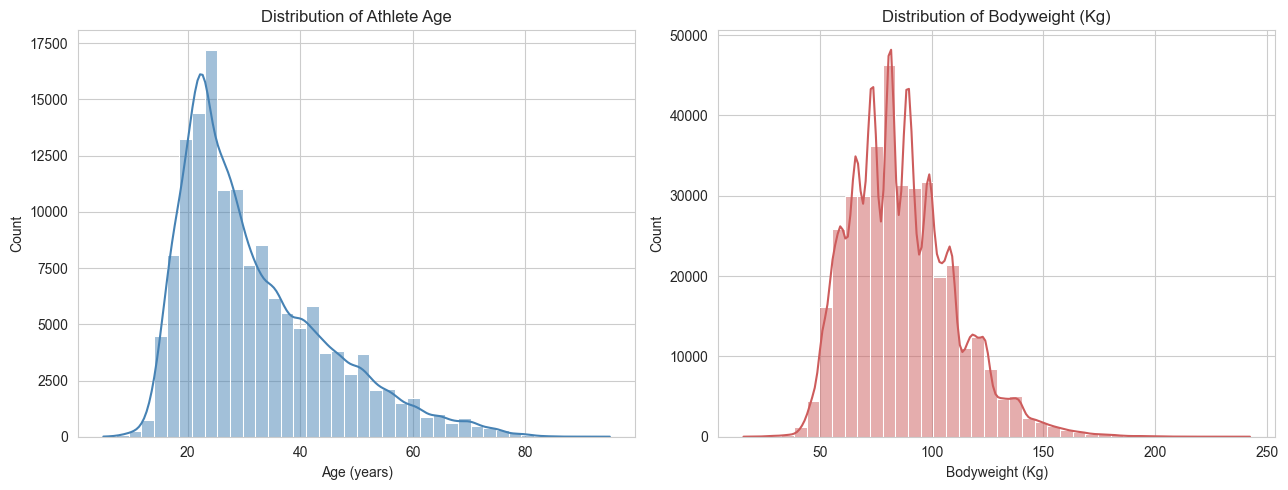

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df_clean['Age'].dropna(), bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Athlete Age')
axes[0].set_xlabel('Age (years)')

sns.histplot(df_clean['BodyweightKg'].dropna(), bins=40, kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Distribution of Bodyweight (Kg)')
axes[1].set_xlabel('Bodyweight (Kg)')
plt.tight_layout()
plt.show()


In [25]:
print(df_clean[['Age','BodyweightKg','TotalKg','Wilks']].describe().round(2))


             Age  BodyweightKg    TotalKg      Wilks
count  145258.00     375386.00  362797.00  361754.00
mean       31.63         86.83     424.06     301.13
std        12.89         23.09     196.32     116.33
min         5.00         15.88      11.00      13.73
25%        22.00         70.20     272.50     237.57
50%        28.00         83.00     424.11     319.72
75%        39.00        100.00     565.00     379.32
max        95.00        242.40    1365.31     779.38


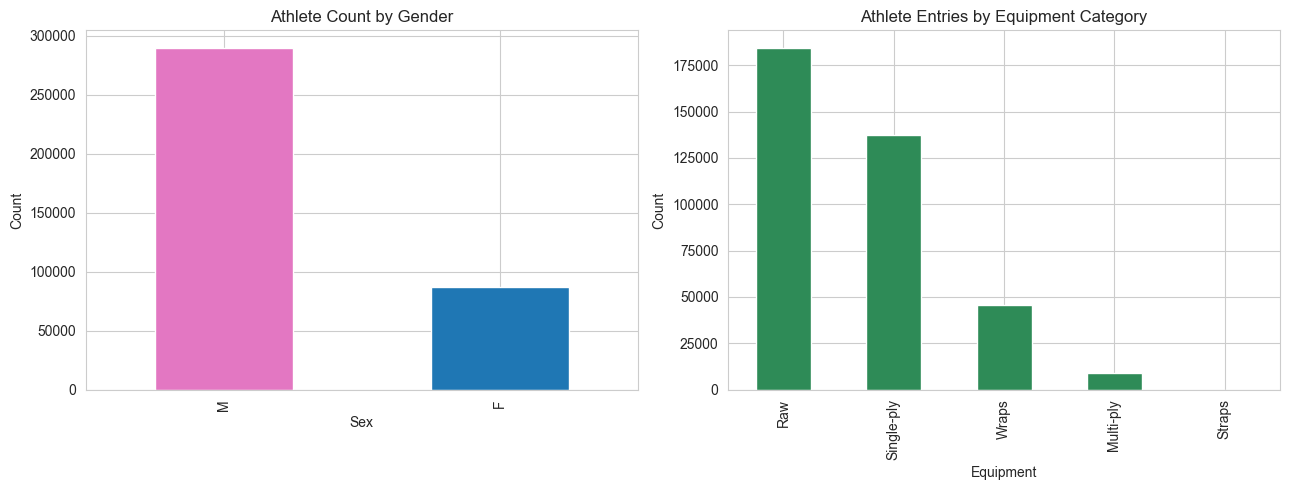

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))
df_clean['Sex'].value_counts().plot(kind='bar', ax=ax[0], color=['#e377c2','#1f77b4'])
ax[0].set_title('Athlete Count by Gender')
ax[0].set_xlabel('Sex'); ax[0].set_ylabel('Count')

df_clean['Equipment'].value_counts().plot(kind='bar', ax=ax[1], color='seagreen')
ax[1].set_title('Athlete Entries by Equipment Category')
ax[1].set_xlabel('Equipment'); ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** The male athlete population is noticeably larger than the female population in this dataset. `Raw` and `Single-ply` are the dominant equipment categories.

**Insight:** Sex and Equipment are highly imbalanced categorical fields — any cross-category comparison should use normalized metrics (averages/rates), not raw counts.

**Business Impact:** Federation marketing and outreach could target growing female and Raw-division participation, which appear to be the fastest-growing but still smaller segments.


### 3.2 Bivariate Analysis

C:\Users\Bhanu\AppData\Local\Temp\ipykernel_25716\1155312436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Sex', y='TotalKg', ax=ax, palette=['#e377c2','#1f77b4'])


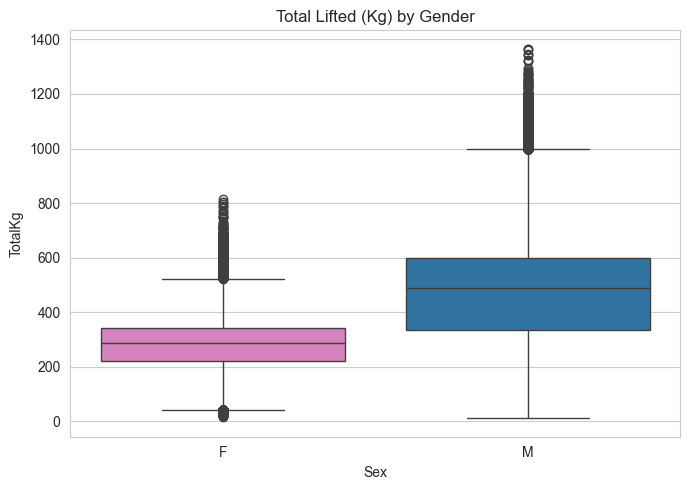

In [48]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df_clean, x='Sex', y='TotalKg', ax=ax, palette=['#e377c2','#1f77b4'])
ax.set_title('Total Lifted (Kg) by Gender')
plt.tight_layout()
plt.show()



C:\Users\Bhanu\AppData\Local\Temp\ipykernel_25716\2783409877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Equipment', y='TotalKg', ax=ax, palette='Set2')


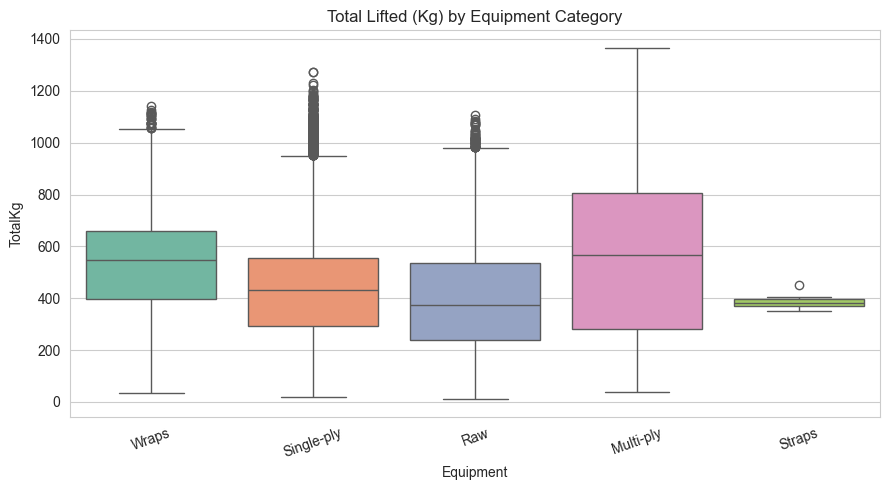

In [28]:
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df_clean, x='Equipment', y='TotalKg', ax=ax, palette='Set2')
ax.set_title('Total Lifted (Kg) by Equipment Category')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


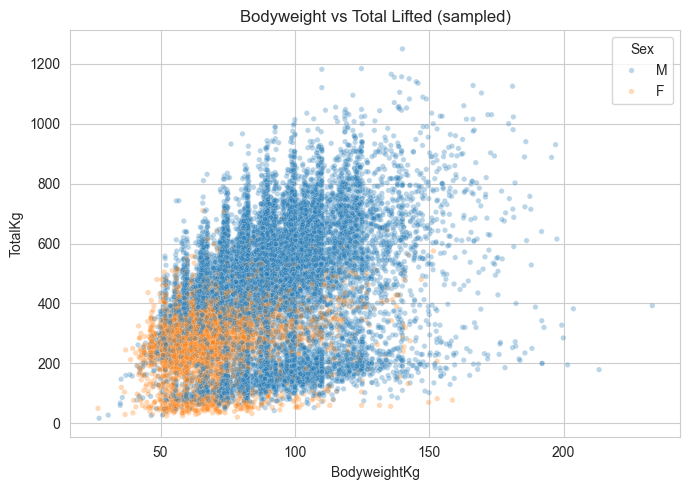

In [29]:
sample = df_clean.sample(min(20000, len(df_clean)), random_state=42)
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=sample, x='BodyweightKg', y='TotalKg', hue='Sex', alpha=0.3, s=15, ax=ax)
ax.set_title('Bodyweight vs Total Lifted (sampled)')
plt.tight_layout()
plt.show()


**Observation:** Male athletes and equipped lifters (Single-ply/Multi-ply, which allow supportive gear) post noticeably higher Total Kg than female or Raw athletes. Total lifted rises with bodyweight but with diminishing/plateauing returns at the high end.

**Insight:** Raw comparisons of Total Kg conflate sex, equipment, and bodyweight effects — this is exactly why the sport uses the bodyweight-normalized **Wilks score** for fair cross-category ranking.

**Business Impact:** Federation award/scouting decisions based on raw Total alone would systematically favor heavier, equipped male lifters — Wilks-based leaderboards are needed for fair recognition across categories.


### 3.3 Multivariate Analysis

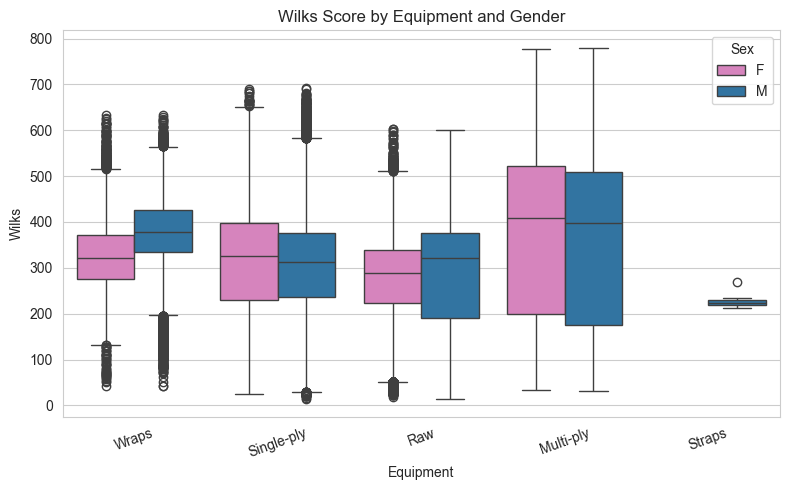

In [49]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df_clean, x='Equipment', y='Wilks', hue='Sex', ax=ax, palette=['#e377c2','#1f77b4'])
ax.set_title('Wilks Score by Equipment and Gender')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


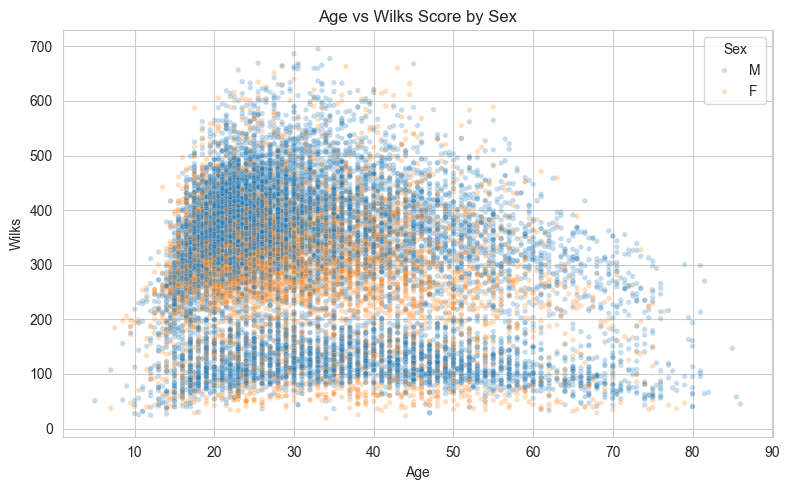

In [31]:
sample2 = df_clean.dropna(subset=['Age']).sample(min(20000, df_clean['Age'].notna().sum()), random_state=42)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=sample2, x='Age', y='Wilks', hue='Sex', alpha=0.25, s=15, ax=ax)
ax.set_title('Age vs Wilks Score by Sex')
plt.tight_layout()
plt.show()


**Observation:** Even on the normalized Wilks score, Equipment and Sex still create visible group differences, and Wilks score peaks in the 20s–30s age range before declining with age.

**Insight:** Peak competitive strength (Wilks-adjusted) is concentrated in early adulthood, consistent with known strength-training physiology; this is a multivariate effect only visible once Age, Sex and Equipment are viewed together.

**Business Impact:** Coaching programs and athlete development pipelines should prioritize the 20–35 age band for elite scouting, while masters (40+) programs should be benchmarked against age-adjusted, not open-division, standards.


## 4. Pivot Table Analysis

In [50]:
pivot1 = pd.pivot_table(df_clean, values='TotalKg', index='Sex', columns='Equipment', aggfunc='mean').round(1)
print("Average Total Kg by Gender x Equipment:")
print(pivot1)


Average Total Kg by Gender x Equipment:
Equipment  Multi-ply    Raw  Single-ply  Straps  Wraps
Sex                                                   
F              374.8  262.8       291.7     NaN  323.0
M              590.9  443.4       448.1   388.2  603.8


In [33]:
pivot2 = pd.pivot_table(df_clean, values='Wilks', index='Sex', columns='Equipment', aggfunc='mean').round(1)
print("Average Wilks Score by Sex x Equipment:")
print(pivot2)


Average Wilks Score by Sex x Equipment:
Equipment  Multi-ply    Raw  Single-ply  Straps  Wraps
Sex                                                   
F              375.0  271.6       307.0     NaN  327.0
M              359.9  288.5       299.1   229.4  378.3


**Observation:** Equipped categories (Single-ply, Multi-ply) show higher average Total Kg than Raw/Wraps/Straps across both sexes, and this gap persists (though shrinks) even on the normalized Wilks score. The 24–29 and 30–39 age groups post the highest average Wilks scores for both sexes.

**Insight:** Equipment provides a measurable mechanical advantage beyond what bodyweight-normalization alone corrects for, and competitive strength peaks in the late-20s-to-30s window.

**Business Impact:** The federation should keep equipment categories strictly separated in rankings and awards (already common practice) and can use the 24–39 age-group benchmark as the target standard for "open division" coaching programs.


## 5. GroupBy Analysis

In [35]:
equip_summary = df_clean.groupby('Equipment', observed=True).agg(
    entries=('Name','count'),
    avg_total=('TotalKg','mean'),
    avg_wilks=('Wilks','mean')
).round(1).sort_values('entries', ascending=False)
print("Category-wise (Equipment) performance summary:")
print(equip_summary)


Category-wise (Equipment) performance summary:
            entries  avg_total  avg_wilks
Equipment                                
Raw          184512      387.2      283.2
Single-ply   137450      428.4      300.1
Wraps         45639      534.3      365.6
Multi-ply      8861      563.7      361.8
Straps            7      388.2      229.4


In [36]:
top_meets = df_clean.groupby('MeetID').agg(
    entries=('Name','count'),
    avg_total=('TotalKg','mean')
).sort_values('entries', ascending=False).head(10).round(1)
print("Top 10 meets by number of entries:")
print(top_meets)


Top 10 meets by number of entries:
        entries  avg_total
MeetID                    
7028       1193      512.0
7021       1191      505.4
7015       1132      490.8
8459        836      317.0
1466        817      503.8
1299        813      311.1
7027        733      503.2
59          705      380.3
8444        589      321.7
7023        560      486.7


In [37]:
dq_rate = (df_clean['Place'] == 'DQ').mean() * 100
print(f"Overall disqualification (DQ) rate: {dq_rate:.2f}%")

dq_by_equip = df_clean.groupby('Equipment', observed=True)['Place'].apply(lambda s: (s=='DQ').mean()*100).round(2)
print("\nDQ rate (%) by Equipment:")
print(dq_by_equip.sort_values(ascending=False))


Overall disqualification (DQ) rate: 3.60%

DQ rate (%) by Equipment:
Equipment
Multi-ply     5.57
Single-ply    4.99
Wraps         2.99
Raw           2.62
Straps        0.00
Name: Place, dtype: float64


**Observation:** `Raw` has by far the most entries, reflecting its growing popularity as unequipped lifting. A handful of meets account for a disproportionate share of total entries. DQ rates vary meaningfully by equipment category.

**Insight:** Participation is concentrated in a small number of large meets and in the Raw category — the federation's growth is being driven primarily by unequipped/Raw competition.

**Business Impact:** Event planning and resource allocation (judging staff, equipment checks, venue size) should prioritize Raw divisions and the small set of high-turnout meets; equipment categories with higher DQ rates may need clearer rule communication or pre-meet equipment checks.


## 6. Data Visualization

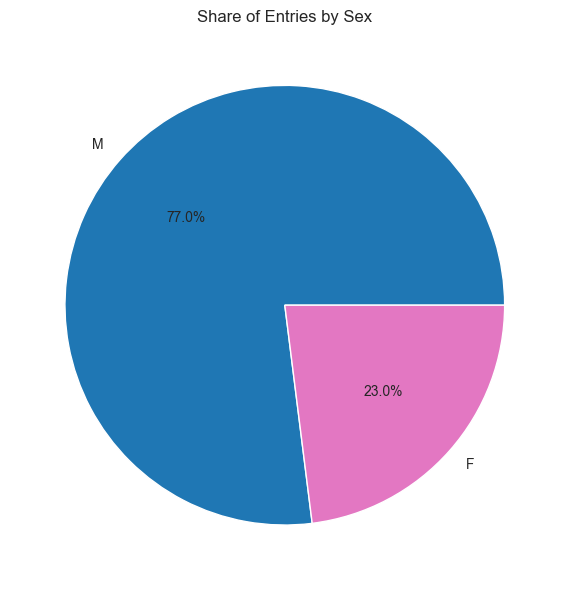

In [38]:
fig, ax = plt.subplots(figsize=(6,6))
df_clean['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, colors=['#1f77b4','#e377c2'])
ax.set_ylabel('')
ax.set_title('Share of Entries by Sex')
plt.tight_layout()
plt.show()


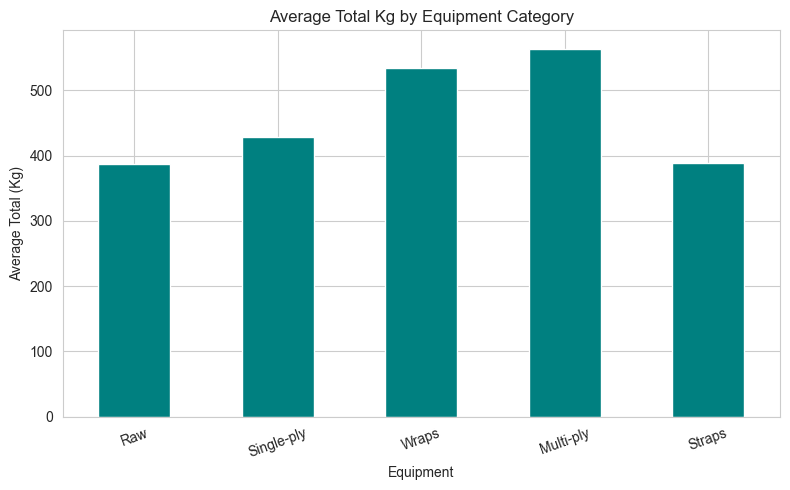

In [39]:
fig, ax = plt.subplots(figsize=(8,5))
equip_summary['avg_total'].plot(kind='bar', ax=ax, color='teal')
ax.set_title('Average Total Kg by Equipment Category')
ax.set_ylabel('Average Total (Kg)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Observation:** Multi-ply and Single-ply lead on raw average Total, while Raw and Wraps sit lower — matching the earlier pivot-table finding.

**Insight:** The bar chart confirms the equipment effect is consistent and large enough to matter for any performance ranking.

**Business Impact:** Any "strongest lifter" marketing claim should always state the equipment category, or it will misrepresent relative achievement.


## 7. Correlation Analysis

In [40]:
numeric_cols = ['Age','BodyweightKg','BestSquatKg','BestBenchKg','BestDeadliftKg','TotalKg','Wilks']
corr = df_clean[numeric_cols].corr().round(2)
print(corr)


                 Age  BodyweightKg  BestSquatKg  BestBenchKg  BestDeadliftKg  \
Age             1.00          0.13        -0.03         0.05           -0.04   
BodyweightKg    0.13          1.00         0.59         0.58            0.57   
BestSquatKg    -0.03          0.59         1.00         0.83            0.84   
BestBenchKg     0.05          0.58         0.83         1.00            0.81   
BestDeadliftKg -0.04          0.57         0.84         0.81            1.00   
TotalKg        -0.18          0.41         0.96         0.55            0.86   
Wilks          -0.25          0.03         0.77         0.25            0.62   

                TotalKg  Wilks  
Age               -0.18  -0.25  
BodyweightKg       0.41   0.03  
BestSquatKg        0.96   0.77  
BestBenchKg        0.55   0.25  
BestDeadliftKg     0.86   0.62  
TotalKg            1.00   0.88  
Wilks              0.88   1.00  


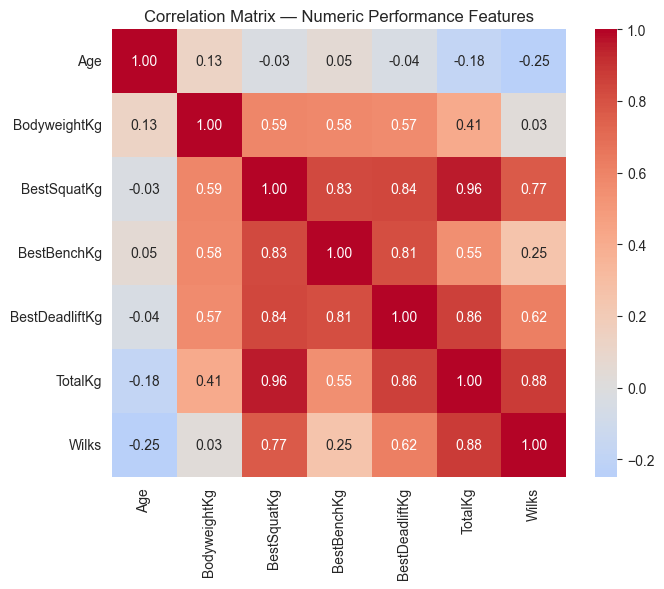

In [51]:
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.2f')
ax.set_title('Correlation Matrix — Numeric Performance Features')
plt.tight_layout()
plt.show()


**Observation:** `BestSquatKg`, `BestBenchKg`, `BestDeadliftKg` and `TotalKg` are all very strongly positively correlated with each other (as expected — Total is their sum). `BodyweightKg` correlates positively with raw lift numbers but far more weakly with `Wilks` (by design, since Wilks removes the bodyweight effect). `Age` has only a weak correlation with performance.

**Insight:** The three individual lifts move together strongly, so Total Kg is a reliable single proxy for overall strength, while Wilks is the right metric whenever bodyweight needs to be controlled for (e.g., cross-weight-class comparisons).

**Business Impact:** For fair "pound-for-pound" rankings, award decisions and athlete-of-the-year selections, the federation should standardize on Wilks, not raw Total, as the primary KPI.


## 8. Problem-Solving Approach

**Problem:** The federation lacked a clear, data-driven view of how sex, equipment, age, and bodyweight drive competitive powerlifting performance, making it hard to run fair rankings, target coaching investment, and plan events.

**Approach:** The 386K-row OpenPowerlifting results dataset was cleaned (structural missing values handled, duplicates removed, inconsistent codes documented), then examined through univariate, bivariate, multivariate, pivot-table and groupby analyses, visualized across standard chart types, and checked for feature correlation.

**How the data helps:** The analysis isolates the size of the equipment effect, the shape of the age-performance curve, the reliability of Wilks vs raw Total as a KPI, and where participation and disqualification risk concentrate — turning raw meet results into decisions the federation can act on (which KPI to standardize on, which age band to target for scouting, which categories need clearer rules, where to focus event resources).


## 9. Business Insights & Recommendations (Summary)

| # | Insight | Recommendation |
|---|---------|-----------------|
| 1 | Equipment (Single-ply/Multi-ply) gives a measurable performance advantage over Raw, even after Wilks normalization | Always report rankings within equipment category, never mixed |
| 2 | Wilks score is only weakly correlated with bodyweight and age, while Total Kg is strongly driven by both | Standardize official "best lifter" awards on Wilks, not Total |
| 3 | Peak Wilks performance occurs in the 24–39 age band | Focus elite scouting and athlete development pipelines on this age range; benchmark masters athletes on age-adjusted standards |
| 4 | Participation is dominated by Raw equipment and a small set of large meets | Prioritize event resources (judges, equipment checks, venue capacity) toward Raw divisions and top meets |
| 5 | DQ rates differ meaningfully by equipment category | Investigate rule clarity / pre-meet equipment checks for higher-DQ categories |
| 6 | Male participation and Total Kg outnumber/outpace female figures | Target outreach and marketing toward growing female participation |

## 10. Conclusion

This EDA converted a large, real-world powerlifting results dataset into a clear picture of how sex, equipment, age, and bodyweight shape competitive performance, and produced concrete, KPI-linked recommendations for the federation's ranking policy, coaching focus, and event planning.
